# Sorting events: from shuffled files to one stream in time order

A Timepix camera does not record images. It records **events**: every time a pixel fires it writes
one row, *where* (`x, y`), *when* (`toa`, time of arrival in 25 ns ticks) and *how much*
(`tot`, time over threshold, a proxy for the deposited charge). One electron fires a few
neighboring pixels within a tick or two, so everything downstream (clusters, positions, images)
needs the events **in time order**.

Two things stand in the way:

1. **The events arrive out of order**, split over many files.
2. **The data are far too big for memory** (one TestSeq1_1k run: ~10 billion events, 188 GB).

This notebook shows how Kronos solves both in one sequential read:

```
raw HDF5 files ──merge_sort──▶ toa-sorted parts ──▶ clustering (notebook 02)
 (out of order)                (bounded memory)
```

**Contents**

1. What the camera writes: the files and the event fields
2. A toy dataset small enough to see every event
3. How the events arrive: time blocks and local shuffling
4. Sorting what is in memory: counting sort (`time_order`)
5. Sorting a stream: `merge_sort`
6. The real run, sorted, and sorting and clustering in one pass

In [1]:
import shutil
import tempfile
import time
from pathlib import Path
from unittest.mock import patch

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, Rectangle
from plot_style import BLUE, GRID, INK, INK_2, MUTED, ORANGE, RED, SERIES, SURFACE

from kronos.cluster import cluster_tables, label_events
from kronos.events import concat, event_columns, fine_columns, fine_steps, fine_toa, fine_tot, read_chunks
from kronos.sort import merge_sort, time_order

%matplotlib ipympl

## 1. What the camera writes

The test run `austin_test` is 32 HDF5 files, one dataset per event field. Here is one of them:

In [2]:
data_directory = Path('/Users/7c2/Desktop/Projects/TimePix/data/2026_09_30_tp4_firsttry')
files = sorted(data_directory.glob('austin_test_*.h5'))
WIDTH, HEIGHT = 448, 512

with h5py.File(files[0], 'r') as h5:
    fields = pd.DataFrame([{'dataset': name, 'rows': len(h5[name]), 'dtype': str(h5[name].dtype)} for name in h5]).set_index('dataset')
print(f'{len(files)} files, e.g. {files[0].name}')
print('empty in this run:', ', '.join(fields.index[fields.rows == 0]))
fields[fields.rows > 0].T

32 files, e.g. austin_test_ep0_ch1_proc0.h5
empty in this run: lvds_timestamp, sw_lvds_fe_timestamp, sw_lvds_re_timestamp, sw_pulse_timestamp, sw_ttl_fe_timestamp, sw_ttl_re_timestamp, ttl_timestamp


dataset,control,ftoa_fall,ftoa_rise,pileup,toa,tot,uftoa_start,uftoa_stop,x,y
rows,3,3410614,3410614,3410614,3410614,3410614,3410614,3410614,3410614,3410614
dtype,uint64,uint8,uint8,uint8,uint64,uint16,uint8,uint8,uint16,uint16


| field | meaning |
|---|---|
| `x`, `y` | pixel column (0–447) and row (0–511) |
| `toa` | time of arrival, in 25 ns ticks of the 40 MHz clock |
| `tot` | time over threshold, in 25 ns ticks: how long the pixel's signal stayed above threshold, ≈ deposited charge |
| `ftoa_rise`, `ftoa_fall`, `uftoa_start`, `uftoa_stop` | sub-tick timing of the rising and falling edge (section 1b) |
| `pileup` | the pixel was hit again while busy |
| the rest | external trigger and timestamp channels, empty in this run |

**How the 32 files divide the events.** The chip is read out in two halves (`ep0`: rows 0–255,
`ep1`: rows 256–511), and each half by 16 processes (`proc0` … `proc15`). The processes take turns
in **time**: time is cut into blocks of 2¹⁴ ticks (410 µs), and process *k* gets the blocks with
`(toa >> 14) % 16 == k`. Inside a file the events are *nearly* in time order. A file's
**disorder** measures how nearly: walk through it keeping the running maximum of `toa`. An event
below the running maximum arrived late, and the disorder is the largest such lateness.

85,180,304 events in all


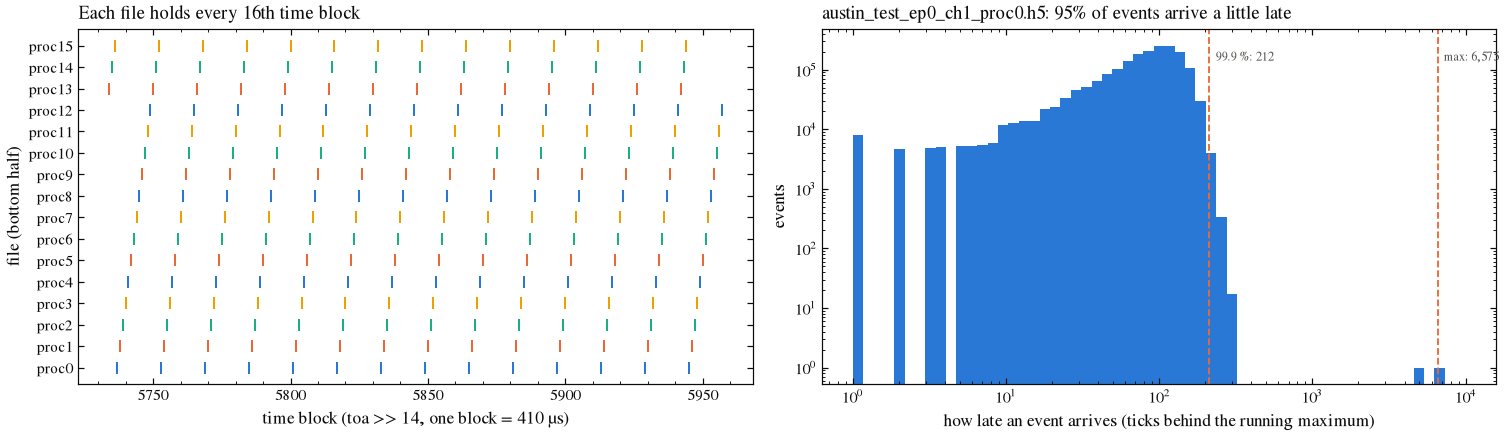

,file,events,chip half,time block,disorder (ticks)
0,austin_test_ep0_ch1_proc0.h5,3410614,bottom (ep0),[9],6575
1,austin_test_ep0_ch1_proc1.h5,3416082,bottom (ep0),[10],10432
2,austin_test_ep0_ch1_proc10.h5,3389125,bottom (ep0),[3],8706
3,austin_test_ep0_ch1_proc11.h5,3385894,bottom (ep0),[4],3045


In [3]:
rows = []
for path in files:
    with h5py.File(path, 'r') as h5:
        head = h5['toa'][:1_000_000].astype(np.int64)
        rows.append(
            {
                'file': path.name,
                'events': len(h5['toa']),
                'chip half': 'bottom (ep0)' if '_ep0_' in path.name else 'top (ep1)',
                'time block': np.unique((head >> 14) % 16).tolist(),
                'disorder (ticks)': int((np.maximum.accumulate(head) - head).max()),
            }
        )
layout = pd.DataFrame(rows)
print(f'{layout.events.sum():,} events in all')

with h5py.File(files[0], 'r') as h5:
    toa0 = h5['toa'][:2_000_000].astype(np.int64)
lateness = np.maximum.accumulate(toa0) - toa0
fig, (ax_blocks, ax_late) = plt.subplots(1, 2, figsize=(14, 4.2))
ep0_files = sorted(files[:16], key=lambda path: int(path.stem.split('proc')[-1]))
for k, path in enumerate(ep0_files):
    with h5py.File(path, 'r') as h5:
        t = h5['toa'][:300_000:300].astype(np.int64)
    ax_blocks.plot(t >> 14, np.full(len(t), k), '|', ms=8, color=SERIES[k % 4])
ax_blocks.set(
    xlabel='time block (toa >> 14, one block = 410 µs)',
    ylabel='file (bottom half)',
    yticks=range(16),
    yticklabels=[f.stem.split('_')[-1] for f in ep0_files],
    title='Each file holds every 16th time block',
)
ax_blocks.yaxis.minorticks_off()  # one tick per file
ax_late.hist(lateness[lateness > 0], bins=np.logspace(0, 4, 60), color=BLUE)
ax_late.set(
    xscale='log',
    yscale='log',
    xlabel='how late an event arrives (ticks behind the running maximum)',
    ylabel='events',
    title=f'{files[0].name}: {np.mean(lateness > 0):.0%} of events arrive a little late',
)
for q, label in ((99.9, '99.9 %'), (100, 'max')):
    v = np.percentile(lateness, q)
    ax_late.axvline(v, color=ORANGE, ls='--', lw=1.2)
    ax_late.text(v * 1.1, ax_late.get_ylim()[1] * 0.3, f'{label}: {v:,.0f}', color=INK_2, fontsize=8)
plt.tight_layout()
plt.show()
layout.head(4)

So the files are **locally shuffled** (most events within a couple of hundred ticks of their place,
none more than a few thousand) and **globally interleaved** (a file holds every 16th block of time,
and the two halves of the chip are in different files). Reading the files one after the other would
jump back and forth in time. Sorting has to put the whole stream into one global time order without
ever holding it all in memory.

### 1b. Reading the fine time

`toa` counts 25 ns ticks. Every hit also carries sub-tick timing from a 640 MHz oscillator that each
group of 8 pixels (a *superpixel*, 2 columns × 4 rows) shares. `kronos.events` decodes it exactly as
the Timepix4 manual's packet decoder (Listing 21.2) does, in **fine units** of 1/128 tick = 195 ps:

| quantity | formula (ticks) | function |
|---|---|---|
| fine time of arrival | `toa − ftoa_rise/16 + (uftoa_start − uftoa_stop)/128 − (15 − SPGroup)/32` | `fine_toa` |
| precise time over threshold | `tot + (ftoa_rise − ftoa_fall)/16 − (uftoa_start − uftoa_stop)/128` | `fine_tot` |

* `ftoa` counts 1.5625 ns oscillator cycles from the hit to the next clock edge; `uftoa` splits one
  cycle into 8 steps of 195 ps.
* `SPGroup` is the 16-row group along a column counted from the chip's edge (`y // 16` in the
  bottom half, `15 − (y − 256) // 16` in the top half). The clock reaches the groups one after
  another, 781 ps apart, so without this term times drift by up to 11.7 ns along a column.
* fToA values above 16 should not occur (16 cycles fill a tick). They come almost only in
  ToT = 0 packets (manual §24.4, which gives no correction); `fine_toa` reads them as `value − 16`.

Two of these terms are easy to get wrong, so check them on the data. Two events from one electron
fire at nearly the same time, so pairs of neighboring events in the same tick (here: the two-event
clusters of the first part, found as in notebook 02) show any timing offset directly.

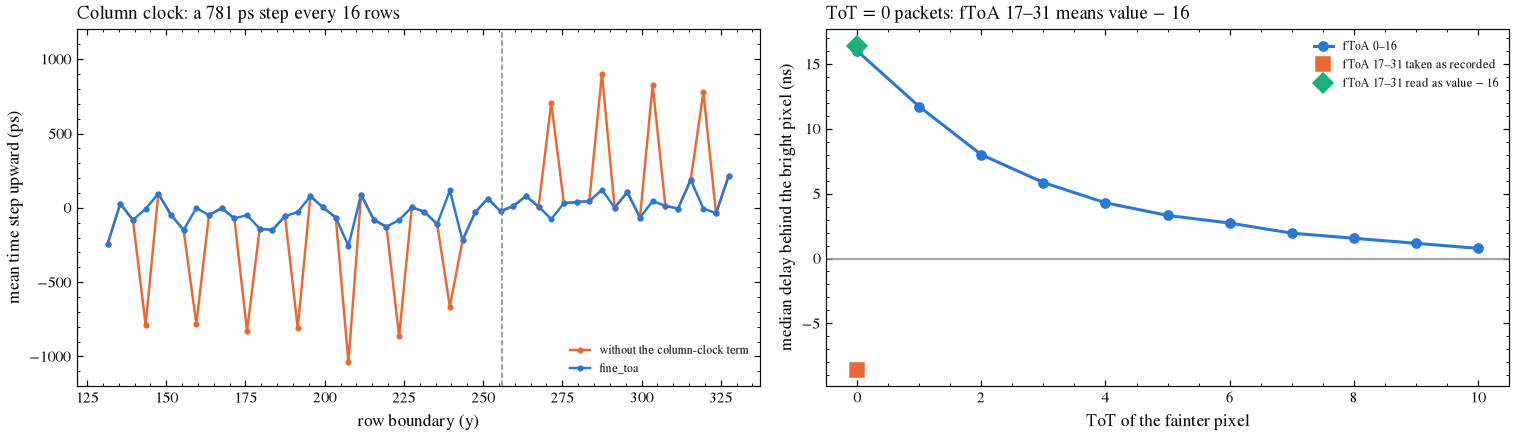

precise ToT: integer ToT ± 0.78 ticks (95 % of pixels); ToT = 0 pixels get their real width


In [4]:
part = next(merge_sort(files, columns=event_columns + fine_columns))
labels = label_events(part['x'], part['y'], part['toa'], 1)
by_label = np.argsort(labels, kind='stable')
two = np.flatnonzero(np.bincount(labels) == 2)
a = by_label[np.searchsorted(labels[by_label], two)]
b = by_label[np.searchsorted(labels[by_label], two) + 1]
x, y, tot = part['x'].astype(np.int64), part['y'].astype(np.int64), part['tot'].astype(np.int64)
ftoa_rise = part['ftoa_rise'].astype(np.int64)
fine = fine_toa(part)
fine_ns = 25 / fine_steps
same_superpixel = (x[a] // 2 == x[b] // 2) & (y[a] // 4 == y[b] // 4)
spgroup = np.where(y < 256, y // 16, 15 - (y - 256) // 16)

fig, (ax_clock, ax_zero) = plt.subplots(1, 2, figsize=(14, 4.2))
# (a) Vertical pairs across a superpixel boundary: the time step upward, by boundary row.
vertical = ~same_superpixel & (x[a] == x[b]) & (tot[a] > 0) & (tot[b] > 0) & (ftoa_rise[a] <= 16) & (ftoa_rise[b] <= 16)
upper, lower = np.where(y[a] > y[b], a, b)[vertical], np.where(y[a] > y[b], b, a)[vertical]
rows_at = np.array([r for r in range(3, 511, 4) if np.sum(y[lower] == r) >= 1000])
for name, times, color in (('without the column-clock term', fine + 4 * (15 - spgroup), ORANGE), ('fine_toa', fine, BLUE)):
    step = (times[upper] - times[lower]) * fine_ns * 1e3
    ax_clock.plot(rows_at + 0.5, [step[y[lower] == r].mean() for r in rows_at], marker='o', ms=3, lw=1.6, color=color, label=name)
ax_clock.axvline(256, color=MUTED, lw=1, ls='--')
ax_clock.set(xlabel='row boundary (y)', ylabel='mean time step upward (ps)', ylim=(-1200, 1200), title='Column clock: a 781 ps step every 16 rows')
ax_clock.legend(loc='lower right', fontsize=8)
# (b) The fainter pixel's delay behind a bright partner, for each fainter-pixel ToT.
faint, bright = np.where(tot[a] <= tot[b], a, b), np.where(tot[a] <= tot[b], b, a)
independent = ~same_superpixel & (tot[bright] >= 10) & (ftoa_rise[bright] <= 16)
delay_ns = (fine[faint] - fine[bright]) * fine_ns
tots = np.arange(0, 11)
ax_zero.plot(
    tots,
    [np.median(delay_ns[independent & (tot[faint] == v) & (ftoa_rise[faint] <= 16)]) for v in tots],
    marker='o',
    lw=2,
    color=BLUE,
    label='fToA 0–16',
)
high = independent & (tot[faint] == 0) & (ftoa_rise[faint] > 16)
ax_zero.plot([0], [np.median(delay_ns[high]) - 25], 's', ms=9, color=ORANGE, label='fToA 17–31 taken as recorded')
ax_zero.plot([0], [np.median(delay_ns[high])], 'D', ms=9, color='#1baf7a', label='fToA 17–31 read as value − 16')
ax_zero.axhline(0, color=MUTED, lw=1)
ax_zero.set(
    xlabel='ToT of the fainter pixel', ylabel='median delay behind the bright pixel (ns)', title='ToT = 0 packets: fToA 17–31 means value − 16'
)
ax_zero.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(
    f'precise ToT: integer ToT ± {np.percentile(np.abs(fine_tot(part) / fine_steps - tot), 95):.2f} ticks (95 % of pixels); ToT = 0 pixels get their real width'
)

* **Left:** without the column-clock term the time jumps by ±781 ps at every 16th row, with opposite
  signs in the two halves (each half is clocked from its outer edge). With it the jumps are gone.
* **Right:** faint pixels fire late (*timewalk*, notebook 02), more so the fainter they are. ToT = 0
  pixels whose fToA is 17–31, taken at face value, would fire 8 ns *before* their bright partner.
  Read as `value − 16` they line up with the other ToT = 0 pixels.

Clustering only needs the coarse `toa`; the fine time and precise ToT are there for timing and energy
when you want them (`merge_sort(files, columns=event_columns + fine_columns)`).

## 2. A toy dataset small enough to see every event

To watch the sorting algorithms work, here is a toy detector: **10 × 10 pixels**, times **1 to 100
ticks**, 55 electrons. Each fires the pixel it hit plus 0–3 edge neighbors, at `t0` or `t0 + 1`,
in roughly the proportions of real data. On the left is what an ordinary camera would give you:
every hit summed over the run, all timing gone. On the right are only the events in an 8-tick slice,
colored by electron: in a short time window the electrons separate cleanly. That is why everything
downstream needs the time order.

110 events from 55 electrons


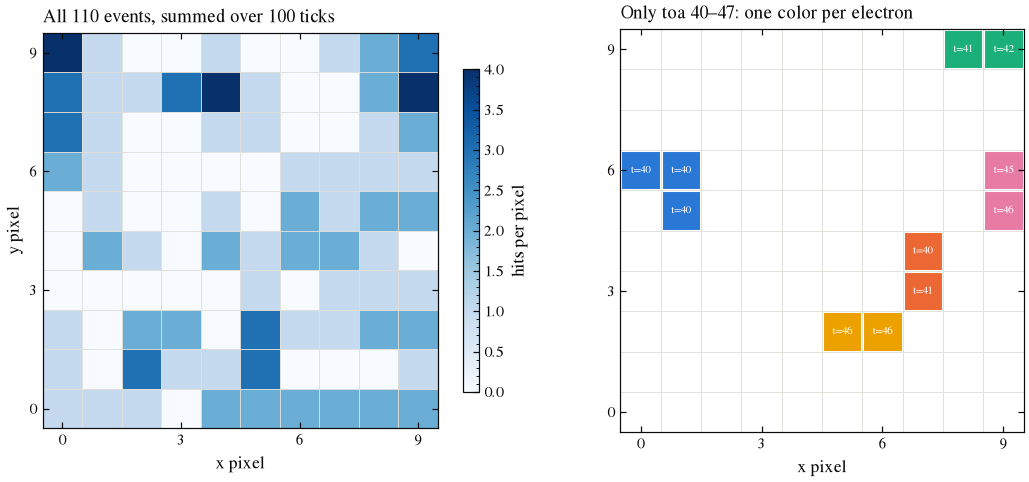

In [5]:
SIZE, T_END, N_ELECTRONS = 10, 100, 55
EDGE_NEIGHBORS = [(1, 0), (-1, 0), (0, 1), (0, -1)]


def pixel_axes(ax, title=None):
    # Square SIZE x SIZE detector axes with a line between every pixel.
    ax.set(xlim=(-0.5, SIZE - 0.5), ylim=(-0.5, SIZE - 0.5), aspect='equal')
    ax.set_xticks(range(0, SIZE, 3)), ax.set_yticks(range(0, SIZE, 3))
    ax.set_xticks(np.arange(-0.5, SIZE), minor=True), ax.set_yticks(np.arange(-0.5, SIZE), minor=True)
    ax.grid(False)
    ax.grid(which='minor', color=GRID, linewidth=0.6)
    ax.tick_params(which='minor', length=0)
    if title:
        ax.set_title(title)


# Each toy electron: a time t0 and the pixels it fires. Electrons too close to an earlier one are redrawn,
# so every electron stays recognizable.
rng = np.random.default_rng(4)
electrons = []
while len(electrons) < N_ELECTRONS:
    t0 = int(rng.integers(1, T_END))
    cx, cy = (int(v) for v in rng.integers(0, SIZE, 2))
    n_pixels = 1 + rng.choice(4, p=[0.36, 0.52, 0.09, 0.03])
    pixels = [(cx, cy)]
    for k in rng.permutation(4):
        dx, dy = EDGE_NEIGHBORS[k]
        if len(pixels) < n_pixels and 0 <= cx + dx < SIZE and 0 <= cy + dy < SIZE:
            pixels.append((cx + dx, cy + dy))
    if not any(abs(t0 - t) <= 4 and abs(px - qx) <= 2 and abs(py - qy) <= 2 for t, others in electrons for qx, qy in others for px, py in pixels):
        electrons.append((t0, pixels))

events = [
    (px, py, t0 + int(rng.integers(0, 2)), int(rng.integers(4, 30)), e) for e, (t0, pixels) in enumerate(sorted(electrons)) for px, py in pixels
]
columns = dict(zip(('x', 'y', 'toa', 'tot', 'electron'), np.array(events).T))
dtypes = {'x': np.uint16, 'y': np.uint16, 'toa': np.uint64, 'tot': np.uint16, 'electron': np.int64}
truth = {name: values.astype(dtypes[name]) for name, values in columns.items()}
print(f'{len(truth["toa"])} events from {N_ELECTRONS} electrons')

fig, (ax_image, ax_slice) = plt.subplots(1, 2, figsize=(10, 4.6))
image = np.zeros((SIZE, SIZE))
np.add.at(image, (truth['y'], truth['x']), 1)
shown = ax_image.imshow(image, origin='lower', cmap='Blues', vmin=0)
pixel_axes(ax_image, f'All {len(truth["toa"])} events, summed over 100 ticks')
fig.colorbar(shown, ax=ax_image, shrink=0.8, label='hits per pixel')
in_slice = (truth['toa'] >= 40) & (truth['toa'] < 48)
for k, e in enumerate(np.unique(truth['electron'][in_slice])):
    mine = in_slice & (truth['electron'] == e)
    for px, py, t in zip(truth['x'][mine], truth['y'][mine], truth['toa'][mine]):
        ax_slice.add_patch(Rectangle((px - 0.5, py - 0.5), 1, 1, color=SERIES[k], ec=SURFACE, lw=2))
        ax_slice.text(px, py, f't={t}', ha='center', va='center', fontsize=7, color='white')
pixel_axes(ax_slice, 'Only toa 40–47: one color per electron')
ax_image.set(xlabel='x pixel', ylabel='y pixel'), ax_slice.set(xlabel='x pixel')
plt.tight_layout()
plt.show()

## 3. How the toy events arrive

The toy files copy the real layout at small scale: **4 files**, time cut into **blocks of 8 ticks**
dealt round-robin (`(toa // 8) % 4`), and each event displaced by up to **3 ticks** inside its file.
They are written in the same HDF5 layout as the real files, so `kronos` reads them the same way.
Each dot below is an event in file order; the gray line is the running maximum and the red arrow
the worst late arrival, the file's disorder.

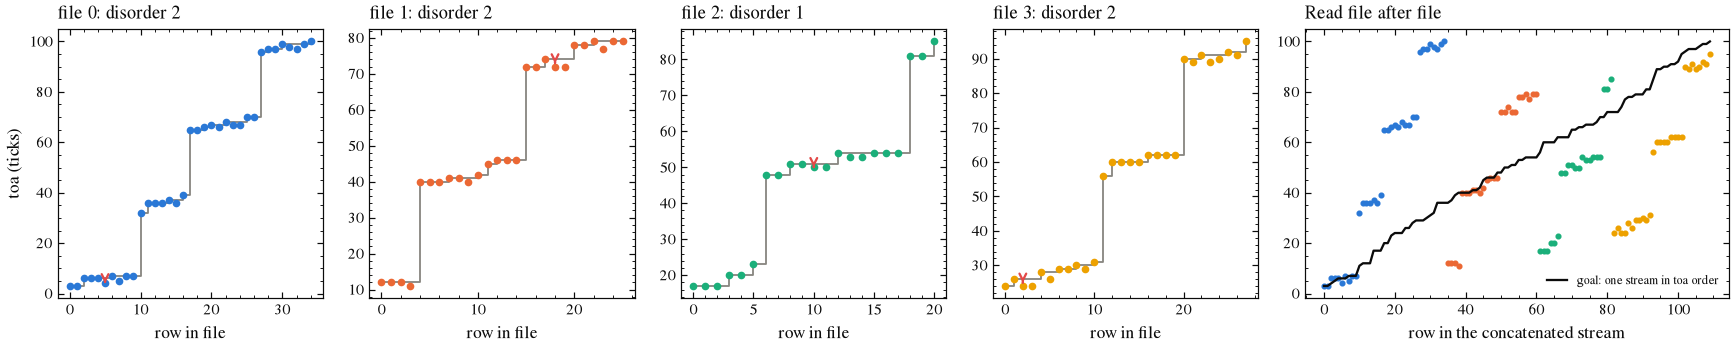

In [6]:
N_FILES, BLOCK, JITTER = 4, 8, 3
workdir = Path(tempfile.mkdtemp(prefix='kronos_toy_'))


def write_files(events, directory, jitter=JITTER, seed=1):
    # Split events into N_FILES HDF5 files by time block; jitter=None shuffles each file fully.
    rng = np.random.default_rng(seed)
    directory.mkdir(parents=True, exist_ok=True)
    owner = (events['toa'].astype(int) // BLOCK) % N_FILES
    paths = []
    for f in range(N_FILES):
        rows = np.flatnonzero(owner == f)
        if jitter is None:
            rows = rng.permutation(rows)
        else:  # sort by a noisy time: each event moves by less than jitter + 1 ticks
            rows = rows[np.argsort(events['toa'][rows] + rng.uniform(0, jitter + 1, len(rows)))]
        path = directory / f'toy_proc{f}.h5'
        with h5py.File(path, 'w') as h5:
            for name in ('x', 'y', 'toa', 'tot'):
                h5[name] = events[name][rows]
        paths.append(path)
    return paths


def disorder(toa):
    toa = np.asarray(toa, np.int64)
    return int((np.maximum.accumulate(toa) - toa).max())


toy_files = write_files(truth, workdir / 'raw')
raw = [concat(list(read_chunks(path))) for path in toy_files]

fig, axes = plt.subplots(1, N_FILES + 1, figsize=(16, 3.4), gridspec_kw={'width_ratios': [1] * N_FILES + [1.6]})
for f, (ax, file_events) in enumerate(zip(axes, raw)):
    toa = file_events['toa'].astype(int)
    running_max = np.maximum.accumulate(toa)
    worst = int(np.argmax(running_max - toa))
    ax.step(range(len(toa)), running_max, where='post', color=MUTED, lw=1.2)
    ax.plot(toa, 'o', ms=4, color=SERIES[f])
    ax.annotate('', xy=(worst, toa[worst]), xytext=(worst, running_max[worst]), arrowprops={'arrowstyle': '->', 'color': RED, 'lw': 1.5})
    ax.set(title=f'file {f}: disorder {disorder(toa)}', xlabel='row in file')
axes[0].set_ylabel('toa (ticks)')
everything = concat(raw)  # file 0, then file 1, ...
start = 0
for f, file_events in enumerate(raw):
    rows = np.arange(start, start + len(file_events['toa']))
    axes[-1].plot(rows, everything['toa'][rows], 'o', ms=3, color=SERIES[f])
    start += len(rows)
axes[-1].plot(np.sort(everything['toa']), color=INK, lw=1.5, label='goal: one stream in toa order')
axes[-1].set(title='Read file after file', xlabel='row in the concatenated stream')
axes[-1].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## 4. Sorting what is in memory: counting sort (`time_order`)

Whatever is in memory gets sorted by `kronos.sort.time_order`. `toa` values are integers, and within
a part they span a small range, so instead of comparing values (O(n log n)) Kronos **counts** them
(O(n + span)):

1. **Count** how many events have each `toa` value.
2. **Prefix sum.** The running total of the counts gives each value's first output slot.
3. **Place.** Walk the input once; put each event in the next free slot of its value.

Walking the input in order makes the sort **stable**: events with equal `toa` keep their input
order. Here are the three steps in plain Python on ten events (the package compiles the same loop
with numba):

input toa : [3 3 6 6 6 4 7 5 7 7]
sorted toa: [3 3 4 5 6 6 6 7 7 7] | same as time_order: True


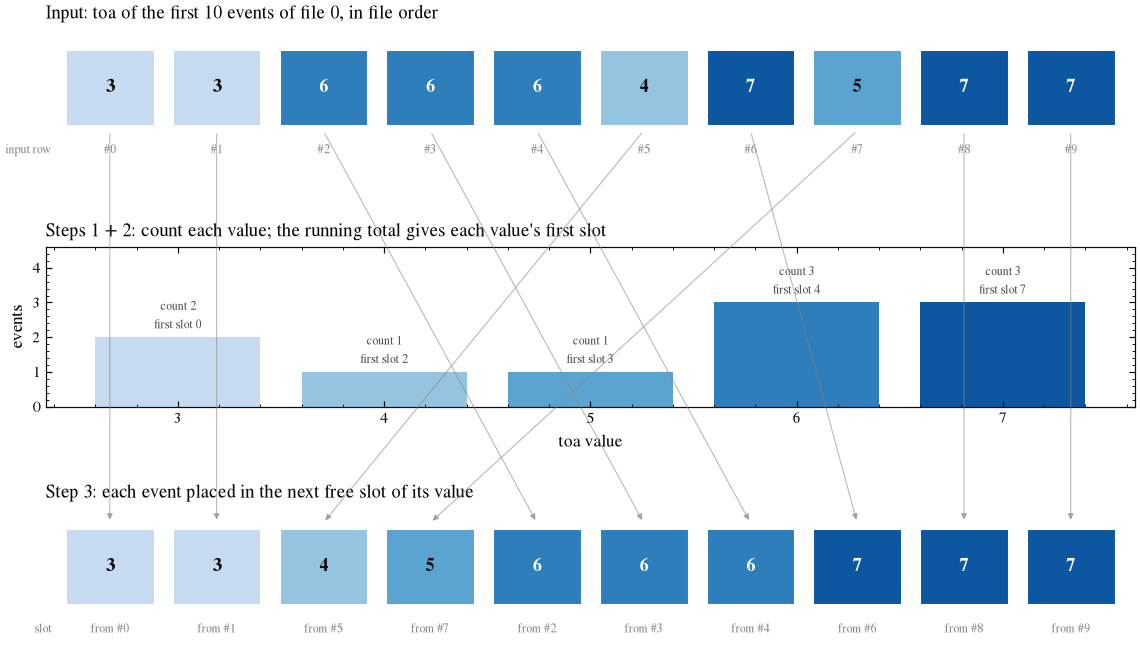

In [7]:
example = raw[0]['toa'][:10].astype(int)  # the first 10 events of file 0
first = example.min()
values = np.arange(first, example.max() + 1)
counts = np.zeros(len(values), dtype=int)
for value in example:  # 1. count
    counts[value - first] += 1
starts = np.cumsum(counts) - counts  # 2. first slot of each value
next_slot = starts.copy()
order = np.empty(len(example), dtype=int)
for i, value in enumerate(example):  # 3. place, in input order
    order[next_slot[value - first]] = i
    next_slot[value - first] += 1
print('input toa :', example)
print('sorted toa:', example[order], '| same as time_order:', np.array_equal(order, time_order(example)))


def shade(value):
    return plt.cm.Blues(0.25 + 0.6 * (value - first) / max(1, np.ptp(values)))


def draw_boxes(ax, toa, labels, label_title):
    for k, (value, label) in enumerate(zip(toa, labels)):
        ax.add_patch(Rectangle((k - 0.42, -0.4), 0.84, 0.8, color=shade(value), ec=SURFACE, lw=2))
        ax.text(k, 0, value, ha='center', va='center', fontsize=12, weight='bold', color='white' if value - first > np.ptp(values) / 2 else INK)
        ax.text(k, -0.65, label, ha='center', va='center', fontsize=8, color=MUTED)
    ax.text(-0.55, -0.65, label_title, ha='right', va='center', fontsize=8, color=MUTED)


fig = plt.figure(figsize=(11, 6.6))
ax_in, ax_count, ax_out = fig.add_axes([0.05, 0.72, 0.9, 0.2]), fig.add_axes([0.05, 0.40, 0.9, 0.22]), fig.add_axes([0.05, 0.06, 0.9, 0.2])
for ax in (ax_in, ax_out):
    ax.set(xlim=(-0.6, len(example) - 0.4), ylim=(-0.9, 0.6))
    ax.axis('off')
draw_boxes(ax_in, example, [f'#{i}' for i in range(len(example))], 'input row')
ax_in.set_title('Input: toa of the first 10 events of file 0, in file order', loc='left')
draw_boxes(ax_out, example[order], [f'from #{i}' for i in order], 'slot')
ax_out.set_title('Step 3: each event placed in the next free slot of its value', loc='left')
ax_count.bar(values, counts, width=0.8, color=[shade(v) for v in values])
for v, c, s in zip(values, counts, starts):
    ax_count.text(v, c + 0.08, f'count {c}\nfirst slot {s}' if c else 'count 0', ha='center', va='bottom', fontsize=8, color=INK_2)
ax_count.set(xticks=values, ylim=(0, counts.max() + 1.6), xlabel='toa value', ylabel='events')
ax_count.set_title("Steps 1 + 2: count each value; the running total gives each value's first slot", loc='left')
ax_count.grid(axis='x', visible=False)
slot_of = np.empty(len(example), int)
slot_of[order] = np.arange(len(example))
to_figure = fig.transFigure.inverted().transform
for i, slot in enumerate(slot_of):  # arrows from each input box to its output slot
    start, end = to_figure(ax_in.transData.transform((i, -0.45))), to_figure(ax_out.transData.transform((slot, 0.45)))
    fig.patches.append(
        FancyArrowPatch(start, end, transform=fig.transFigure, arrowstyle='-|>', mutation_scale=8, color=MUTED, lw=0.7, alpha=0.6, zorder=0)
    )
plt.show()

Counting needs one counter per possible value, so it pays off when the span of values is small
compared with the number of events. Inside a real part (millions of events over a few million ticks)
it is, and `time_order` falls back to `argsort` when it is not. On a real part (section 6) counting is
several times faster than numpy's stable argsort.

## 5. Sorting a stream: `merge_sort`

On real data we cannot load everything and then sort. `merge_sort` reads all files **once, front to
back, in chunks**, and hands on toa-sorted **parts** as soon as it can prove they are final. The proof
needs one number, `max_disorder`, an upper bound on any file's disorder:

> If the newest `toa` read so far from file *f* is `newest[f]`, every unread event of that file has
> `toa ≥ newest[f] − max_disorder`. So no unread event, in any file, is older than
>
> &nbsp;&nbsp;&nbsp;&nbsp;**`safe = min over files of newest[f] − max_disorder`**.
>
> Everything in memory older than `safe` can be sorted and handed on: nothing will ever be
> inserted before it.

The loop:

1. Read the next chunk from the file that is **furthest behind** in time (smallest `newest`). This
   keeps the files in step and pushes `safe` forward as fast as possible.
2. Once the buffer holds enough events, split it at `safe`: older events are counting-sorted and
   **yielded as a part**; younger ones stay in the buffer.
3. If a chunk ever holds an event older than what was already yielded, the files are more shuffled
   than `max_disorder`, and `merge_sort` raises `ValueError` rather than return a wrong order.

Toy settings: chunks of 6 rows, `part_rows = 12`, `max_disorder = 4` ticks (the toy files have
disorder ≤ 3). The real defaults are chunks of 200 000 rows, parts of 2 000 000 and
`max_disorder = 65 536`. To watch it, we run the **real** `merge_sort` and only *spy* on it: its
chunk reader is wrapped so that every chunk read is logged, and every part it yields too.

In [8]:
CHUNK_ROWS, PART_ROWS, MAX_DISORDER = 6, 12, 4
log = []  # ('read', file, first_row, chunk) or ('part', part), in the order they happen


def spying_read_chunks(path, columns, chunk_rows):
    for k, chunk in enumerate(read_chunks(path, columns, chunk_rows)):
        log.append(('read', toy_files.index(path), k * chunk_rows, chunk))
        yield chunk


with patch('kronos.sort.read_chunks', spying_read_chunks):
    for toy_part in merge_sort(toy_files, MAX_DISORDER, CHUNK_ROWS, PART_ROWS):
        log.append(('part', toy_part))

toy_parts = [entry[1] for entry in log if entry[0] == 'part']
streamed = concat(toy_parts)
in_memory = everything['toa'][time_order(everything['toa'])]
print(
    f'{sum(e[0] == "read" for e in log)} chunk reads, {len(toy_parts)} parts; same order as sorting everything in memory: {np.array_equal(streamed["toa"], in_memory)}'
)
pd.DataFrame(
    {'events': [len(p['toa']) for p in toy_parts], 'first toa': [p['toa'][0] for p in toy_parts], 'last toa': [p['toa'][-1] for p in toy_parts]}
).rename_axis('part')

20 chunk reads, 5 parts; same order as sorting everything in memory: True


,events,first toa,last toa
part,,,
0,20,3,23
1,29,24,46
2,21,48,62
3,32,65,95
4,8,96,100


Now replay the log. Each panel is the state right after one chunk read (ringed in orange) and any
part yielded in response. Each lane is a file and each dot an event at its `toa`:

* **hollow gray**: still on disk; **blue**: read, waiting in memory; **dark**: sorted and yielded in a
  part (shaded region),
* **▼ orange**: each file's `newest` toa; the **dashed orange line** is `safe`.

The reader always tops up the file whose ▼ is furthest left, `safe` trails the slowest file by
`max_disorder`, and memory only ever holds a narrow band of time.

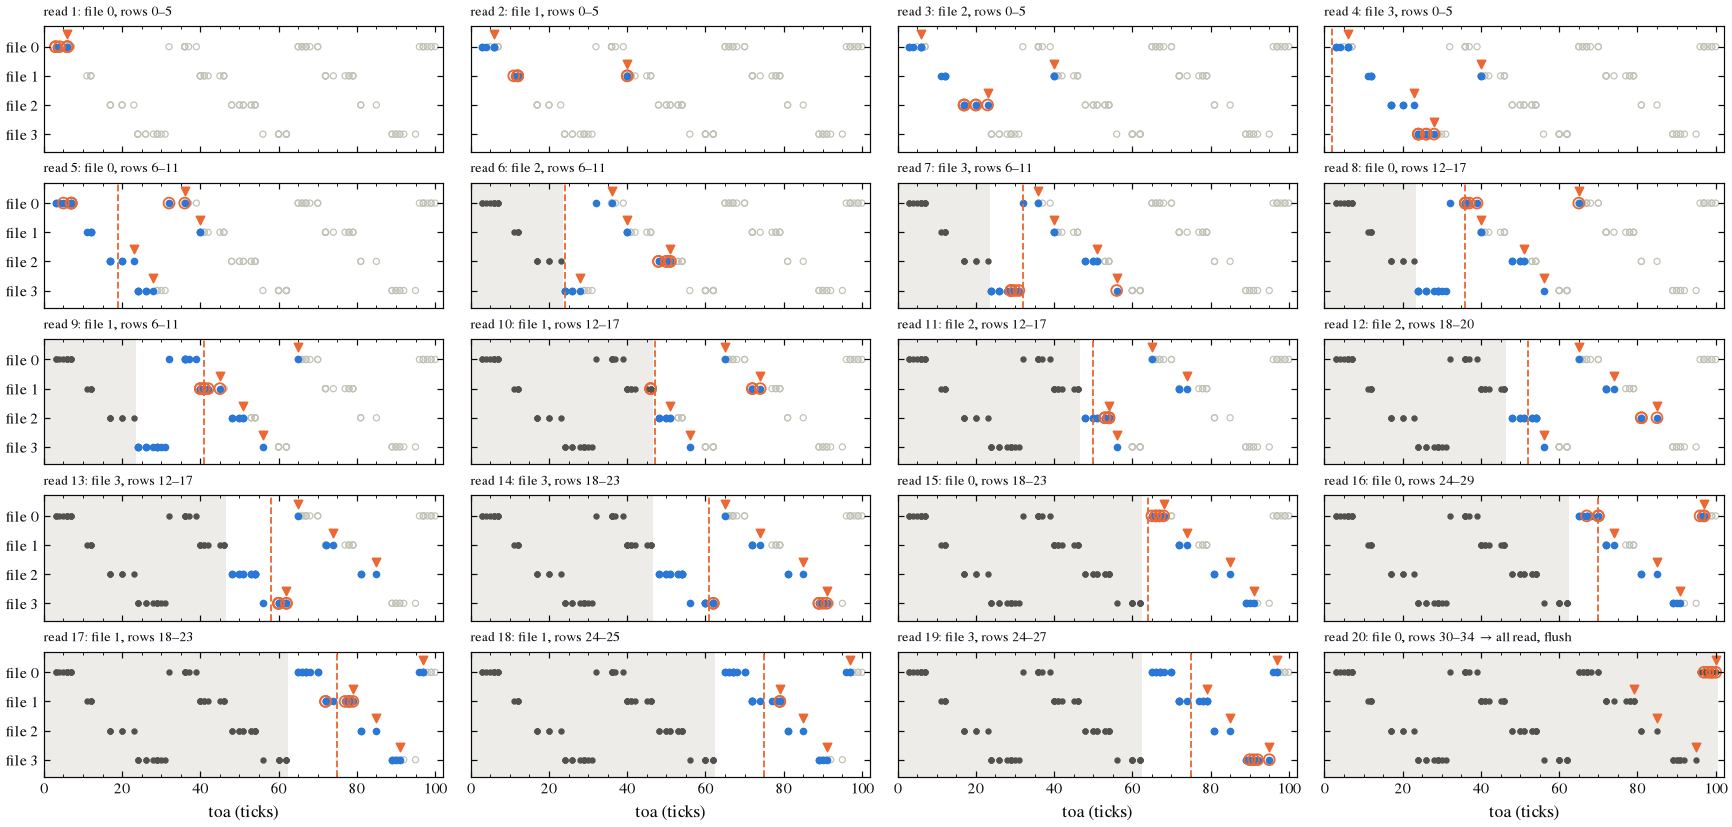

In [9]:
file_of = np.concatenate([np.full(len(r['toa']), f) for f, r in enumerate(raw)])
row_of = np.concatenate([np.arange(len(r['toa'])) for r in raw])
toa_of = everything['toa'].astype(int)
state = np.zeros(len(toa_of), int)  # 0 on disk, 1 in memory, 2 yielded
newest = np.full(N_FILES, -1)
done_until, frames = -1, []
for entry in log:
    if entry[0] == 'read':
        _, f, first_row, chunk = entry
        state[(file_of == f) & (row_of >= first_row) & (row_of < first_row + len(chunk['toa']))] = 1
        newest[f] = max(newest[f], int(chunk['toa'].max()))
        frames.append([state.copy(), newest.copy(), done_until, f, first_row, len(chunk['toa'])])
    else:  # a part was yielded right after the latest read: show it in that frame
        done_until = int(entry[1]['toa'].max())
        state[(state == 1) & (toa_of <= done_until)] = 2
        frames[-1][0], frames[-1][2] = state.copy(), done_until

n_cols = 4
n_rows = -(-len(frames) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 1.55 * n_rows), sharex=True, sharey=True)
lane = N_FILES - 1 - file_of
for k, (ax, (st, nw, done, f, first_row, n)) in enumerate(zip(axes.flat, frames)):
    if done >= 0:
        ax.axvspan(0, done + 0.5, color=GRID, alpha=0.6, lw=0)
    ax.scatter(toa_of[st == 0], lane[st == 0], s=16, facecolor='none', edgecolor='#c3c2b7', lw=0.8)
    ax.scatter(toa_of[st == 1], lane[st == 1], s=16, color=BLUE)
    ax.scatter(toa_of[st == 2], lane[st == 2], s=10, color=INK_2)
    read_now = (file_of == f) & (row_of >= first_row) & (row_of < first_row + n)
    ax.scatter(toa_of[read_now], lane[read_now], s=50, facecolor='none', edgecolor=ORANGE, lw=1.2)
    reading = nw >= 0
    ax.scatter(nw[reading], N_FILES - 1 - np.flatnonzero(reading) + 0.42, marker='v', s=30, color=ORANGE)
    if reading.all() and k < len(frames) - 1:
        ax.axvline(nw.min() - MAX_DISORDER, color=ORANGE, ls='--', lw=1.2)
    last = '  → all read, flush' if k == len(frames) - 1 else ''
    ax.set_title(f'read {k + 1}: file {f}, rows {first_row}–{first_row + n - 1}{last}', fontsize=9, weight='normal')
    ax.set(ylim=(-0.6, N_FILES - 0.3), xlim=(0, T_END + 2), yticks=range(N_FILES), yticklabels=[f'file {N_FILES - 1 - i}' for i in range(N_FILES)])
    ax.yaxis.minorticks_off()  # one tick per file
for ax in axes.flat[len(frames) :]:
    ax.axis('off')
for ax in axes[-1]:
    ax.set_xlabel('toa (ticks)')
plt.tight_layout(h_pad=0.6)
plt.show()

**A promise that is too small.** `max_disorder` is a promise about the files. Promise 1 tick when the
files are shuffled by 3, and `merge_sort` finds an event older than a part it already yielded, and
stops:

In [10]:
try:
    list(merge_sort(toy_files, max_disorder=1, chunk_rows=CHUNK_ROWS, part_rows=PART_ROWS))
except ValueError as error:
    print('ValueError:', str(error).replace(str(workdir), '…'))
shutil.rmtree(workdir)  # the toy files are no longer needed

ValueError: …/raw/toy_proc1.h5 jumps back more than 1 ticks: raise max_disorder


A larger `max_disorder` is always correct; it only holds more events in memory before they are
safe. Real files have a disorder of at most about one time block (16 384 ticks; the worst whole
`austin_test` file is 16 228), and the default is 65 536.

## 6. The real run

All 32 files through `merge_sort` with the default settings. Memory holds one part plus one chunk per
file at a time, so the peak is set by the settings (~1.4 GB), not by the size of the run.

In [11]:
start = time.perf_counter()
part_rows, spans, in_order = [], [], True
for real_part in merge_sort(files):
    toa = real_part['toa']
    part_rows.append(len(toa))
    spans.append(int(toa[-1] - toa[0]))
    in_order &= bool(np.all(toa[1:] >= toa[:-1]))
sort_seconds = time.perf_counter() - start
n_events = sum(part_rows)
print(
    f'{n_events:,} events in {len(part_rows)} parts, {sort_seconds:.1f} s ({n_events / sort_seconds / 1e6:.0f} M events/s), every part in toa order: {in_order}'
)
print(f'part size: median {np.median(part_rows) / 1e6:.1f} M events, spanning {np.median(spans) * 25e-9 * 1e3:.0f} ms of beam')

toa = part['toa'][np.random.default_rng(0).permutation(len(part['toa']))]  # one real part, shuffled
time_order(toa)  # compile once before timing
start = time.perf_counter()
np.argsort(toa, kind='stable')
t_argsort = time.perf_counter() - start
start = time.perf_counter()
time_order(toa)
t_count = time.perf_counter() - start
print(
    f'one real part ({len(toa) / 1e6:.1f} M events): counting sort {t_count * 1e3:.0f} ms, numpy stable argsort {t_argsort * 1e3:.0f} ms ({t_argsort / t_count:.0f}× slower)'
)

85,180,304 events in 17 parts, 1.6 s (54 M events/s), every part in toa order: True
part size: median 5.0 M events, spanning 59 ms of beam


one real part (5.1 M events): counting sort 42 ms, numpy stable argsort 1471 ms (35× slower)


### Sorting and clustering in one pass

Sorted events are rarely the goal; clusters are (notebook 02). Clustering needs exactly what
`merge_sort` produces, parts in time order, so the two run as **one pipeline**. Each part is
clustered as soon as it is yielded, and the sorted events never touch the disk:

```python
cluster_parts(merge_sort(files), 'outputs/<experiment>/clusters', dt_max=1)
```

Writing the sorted events and reading them back would add a full write and read of the data for
nothing. (`save_parts` and `load_parts` in `kronos.events` do it when you do want the sorted events
for something else.) Here is what clustering adds on top of the sort:

In [12]:
start = time.perf_counter()
n_clusters = sum(len(table) for table in cluster_tables(merge_sort(files), dt_max=1))
both_seconds = time.perf_counter() - start
print(f'sort only: {sort_seconds:.1f} s; sort and cluster in one pass: {both_seconds:.1f} s for {n_events:,} events -> {n_clusters:,} clusters')

sort only: 1.6 s; sort and cluster in one pass: 5.5 s for 85,180,304 events -> 47,786,372 clusters


## Summary

| step | function | idea | memory |
|---|---|---|---|
| read | `read_chunks` | consecutive row ranges of one file | one chunk |
| decode fine time | `fine_toa`, `fine_tot` | the manual's decoder, plus fToA 17–31 read as `value − 16` | — |
| sort inside memory | `time_order` | count each `toa`, prefix sum, place: O(n + span), stable | one part |
| sort a stream | `merge_sort` | read the file furthest behind; everything older than `min(newest) − max_disorder` is final | one part + one chunk per file |

The output, parts in time order, goes straight into clustering in the same pass. Notebook 02 is about
how clusters are defined; notebook 03 about where in a cluster the electron landed.